In [21]:
# ESSENTIAL LIBRARIES FOR BUSINESS ANALYTICS
# ============================================

# Data Manipulation & Analysis

# Visualization
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# Statistical Analysis

# Utility

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# ============================================
# PANDAS CONFIGURATION
# ============================================

# Display settings
pd.set_option('display.max_columns', 100)        # Show all columns
pd.set_option('display.max_rows', 100)           # Show more rows
pd.set_option('display.width', 1000)             # Wider display
pd.set_option('display.precision', 2)            # 2 decimal places
pd.set_option('display.float_format', '{:,.2f}'.format)  # Format numbers
pd.set_option('display.max_colwidth', 50)        # Column width
pd.set_option('display.max_info_columns', 100)   # More info columns
pd.set_option('display.max_info_rows', 100)      # More info rows

# Memory optimization
pd.set_option('mode.chained_assignment', 'warn')  # Warn on chain assignment

# ============================================
# VISUALIZATION CONFIGURATION
# ============================================

# Matplotlib Configuration
plt.rcParams.update({
    # Figure Settings
    'figure.figsize': (12, 6),           # Default figure size
    'figure.dpi': 100,                   # Screen resolution
    'figure.facecolor': 'white',         # Figure background
    'figure.edgecolor': 'white',         # Figure border
    
    # Font & Text
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Helvetica'],
    'font.size': 11,                     # Base font size
    'axes.titlesize': 14,                # Title size
    'axes.labelsize': 12,                # Label size
    'xtick.labelsize': 10,               # X-tick size
    'ytick.labelsize': 10,               # Y-tick size
    
    # Axes Styling
    'axes.spines.top': False,            # Remove top spine
    'axes.spines.right': False,          # Remove right spine
    'axes.grid': True,                   # Show grid
    'grid.alpha': 0.3,                   # Grid transparency
    'grid.linestyle': '--',              # Grid style
    'grid.color': '#CCCCCC',             # Grid color
    
    # Colors
    'axes.prop_cycle': plt.cycler('color', [
        '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
        '#3B60E4', '#A34D9F', '#20A39E', '#EF5B5B', '#FFBA08'
    ]),
    
    # Legend
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    'legend.edgecolor': '#CCCCCC',
    'legend.fontsize': 10,
    
    # Save settings
    'savefig.dpi': 300,                  # High-res saving
    'savefig.bbox': 'tight',             # Tight layout
    'savefig.facecolor': 'white',
    'savefig.format': 'png'
})

# Seaborn Configuration
sns.set_theme(style="whitegrid")  # Base theme
sns.set_palette("husl")           # Color palette

# Custom color palettes for business contexts
BUSINESS_PALETTES = {
    'primary': ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B'],
    'corporate': ['#003f5c', '#58508d', '#bc5090', '#ff6361', '#ffa600'],
    'performance': ['#2ecc71', '#e74c3c', '#f39c12', '#3498db', '#9b59b6'],
    'kpi': ['#27ae60', '#c0392b', '#f39c12', '#2980b9', '#8e44ad'],
    'gradient_green': sns.light_palette("#2ecc71", as_cmap=True),
    'gradient_red': sns.light_palette("#e74c3c", as_cmap=True),
    'gradient_blue': sns.light_palette("#3498db", as_cmap=True)
}

# ============================================
# BUSINESS INSIGHTS FUNCTIONS
# ============================================

class BusinessInsights:
    """Quick statistical and business insight functions."""
    
    @staticmethod
    def describe_business(df, target_col=None):
        """Generate business-focused data description."""
        desc = df.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
        
        # Add business metrics
        desc.loc['skewness'] = df.skew()
        desc.loc['kurtosis'] = df.kurtosis()
        desc.loc['missing'] = df.isnull().sum()
        desc.loc['missing_pct'] = (df.isnull().sum() / len(df)) * 100
        desc.loc['unique_values'] = df.nunique()
        
        return desc
    
    @staticmethod
    def correlation_insights(df, target, top_n=10):
        """Get top correlations with target variable."""
        correlations = df.corr()[target].sort_values(ascending=False)
        
        print("\nTOP CORRELATIONS WITH '{}'".format(target))
        print("="*50)
        
        for col, corr in correlations.items():
            if col == target:
                continue
            strength = "Strong" if abs(corr) > 0.7 else "Medium" if abs(corr) > 0.5 else "Weak"
            direction = "positive" if corr > 0 else "negative"
            print(f"{col}: {corr:.3f} ({direction}, {strength})")
        
        return correlations
    
    @staticmethod
    def value_ranges(df, cols=None):
        """Show min, max, and range for business understanding."""
        if cols is None:
            cols = df.select_dtypes(include=[np.number]).columns
        
        ranges = pd.DataFrame({
            'Min': df[cols].min(),
            'Q25': df[cols].quantile(0.25),
            'Median': df[cols].median(),
            'Q75': df[cols].quantile(0.75),
            'Max': df[cols].max(),
            'Range': df[cols].max() - df[cols].min(),
            'IQR': df[cols].quantile(0.75) - df[cols].quantile(0.25)
        })
        
        return ranges.round(2)

# ============================================
# PROFESSIONAL PLOTTING FUNCTIONS
# ============================================

def setup_plot_style(figsize=(12, 6), title=None, xlabel=None, ylabel=None):
    """Quick professional plot setup."""
    fig, ax = plt.subplots(figsize=figsize)
    
    if title:
        ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=12, fontweight='500')
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=12, fontweight='500')
    
    # Professional styling
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    return fig, ax

def save_plot(fig, filename, folder="visualizations", formats=['png', 'pdf']):
    """Save plot in multiple formats."""
    Path(folder).mkdir(parents=True, exist_ok=True)
    
    for fmt in formats:
        filepath = Path(folder) / f"{filename}.{fmt}"
        fig.savefig(filepath, dpi=300, bbox_inches='tight', facecolor='white')
    
    print(f"Plot saved: {folder}/{filename}.{formats}")
    plt.show()

# ============================================
# QUICK EDA FUNCTION
# ============================================

def quick_business_eda(df, target_col=None):
    """Complete quick EDA for business understanding."""
    bi = BusinessInsights()
    
    print("="*60)
    print("BUSINESS DATA OVERVIEW")
    print("="*60)
    print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print(f"Date Range: {df.index.min()} to {df.index.max()}" if hasattr(df.index, 'min') else "")
    
    print("\n" + "="*60)
    print("DATA TYPES")
    print("="*60)
    print(df.dtypes.value_counts())
    
    print("\n" + "="*60)
    print("MISSING VALUES (>0%)")
    print("="*60)
    missing = (df.isnull().sum() / len(df) * 100)
    missing = missing[missing > 0].sort_values(ascending=False)
    if len(missing) > 0:
        print(missing)
    else:
        print("No missing values!")
    
    if target_col and target_col in df.columns:
        print("\n" + "="*60)
        print(f"TARGET VARIABLE: {target_col}")
        print("="*60)
        print(df[target_col].describe())
        bi.correlation_insights(df, target_col)
    
    print("\n" + "="*60)
    print("NUMERICAL FEATURES SUMMARY")
    print("="*60)
    display(bi.describe_business(df.select_dtypes(include=[np.number])))

# ============================================
# INITIALIZATION CHECK
# ============================================

def check_environment():
    """Verify environment setup."""
    print("Environment Ready!")
    print(f"• Pandas {pd.__version__}")
    print(f"• NumPy {np.__version__}")
    print(f"• Matplotlib {plt.matplotlib.__version__}")
    print(f"• Seaborn {sns.__version__}")
    print(f"• Plotly {plotly.__version__}")
    print(f"• Scipy {stats.__version__ if hasattr(stats, '__version__') else 'Installed'}")
    print("\nColor palettes available: BUSINESS_PALETTES")
    print("Business tools loaded: BusinessInsights()")

# Run environment check
check_environment()
def check_environment():
    """Verify environment setup."""

    print(" Environment Ready!")
    print(f"• Pandas {pd.__version__}")
    print(f"• NumPy {np.__version__}")
    print(f"• Matplotlib {plt.matplotlib.__version__}")
    print(f"• Seaborn {sns.__version__}")
    print(f"• Plotly {plotly.__version__}")
    print(f"• Scipy {stats.__version__ if hasattr(stats, '__version__') else 'Installed'}")
    print("\n Color palettes available: BUSINESS_PALETTES")
    print(" Business tools loaded: BusinessInsights()")
# Run environment check
check_environment()

Environment Ready!
• Pandas 2.3.1
• NumPy 2.2.6
• Matplotlib 3.10.3
• Seaborn 0.13.2
• Plotly 6.3.0
• Scipy Installed

Color palettes available: BUSINESS_PALETTES
Business tools loaded: BusinessInsights()
 Environment Ready!
• Pandas 2.3.1
• NumPy 2.2.6
• Matplotlib 3.10.3
• Seaborn 0.13.2
• Plotly 6.3.0
• Scipy Installed

 Color palettes available: BUSINESS_PALETTES
 Business tools loaded: BusinessInsights()


In [ ]:
def load_curated_data(dataset_name="user_activity"):
    """
    Load curated dataset with automatic path detection.
    """
    from pathlib import Path
    
    # Possible locations
    possible_paths = [
        Path(r"G:\Study\DATA SCINCE\PROJECTS\POTFOLIO\telecom-consumption-intelligence\data\curated") / f"{dataset_name}_curated.parquet",
        Path("data/curated") / f"{dataset_name}_curated.parquet",
        Path("curated") / f"{dataset_name}_curated.parquet",
        Path("../data/curated") / f"{dataset_name}_curated.parquet",
        Path.cwd() / "data" / "curated" / f"{dataset_name}_curated.parquet",
    ]
    
    for path in possible_paths:
        if path.exists():
            df = pd.read_parquet(path)
            print(f"✓ Loaded: {path}")
            print(f"  Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
            return df
    
    # If not found
    raise FileNotFoundError(
        f"Dataset '{dataset_name}_curated.parquet' not found in:\n" +
        "\n".join(f"  • {p}" for p in possible_paths)
    )


df = load_curated_data("user_activity")

✓ Loaded: G:\Study\DATA SCINCE\PROJECTS\POTFOLIO\telecom-consumption-intelligence\data\curated\user_activity_curated.parquet
  Shape: 10,006 rows × 18 columns


In [26]:
# ============================================
#  DATA SUMMARY
# ============================================

def data_summary(df, name="Dataset"):
    """
    Generate a comprehensive yet quick data summary.
    """
    print("="*70)
    print(f" {name.upper()} SUMMARY")
    print("="*70)
    
    # Basic info
    print(f"\n Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f" Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    # Data types summary
    print(f"\n📋 Data Types:")
    for dtype in df.dtypes.value_counts().index:
        count = df.dtypes.value_counts()[dtype]
        print(f"   • {dtype}: {count} columns")
    
    # Missing values
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_summary = pd.DataFrame({
        'Missing': missing[missing > 0],
        '%': missing_pct[missing > 0]
    })
    
    if len(missing_summary) > 0:
        print(f"\n  Missing Values:")
        print(missing_summary.round(2))
    else:
        print(f"\n No missing values")
    
    # Duplicates
    dupes = df.duplicated().sum()
    if dupes > 0:
        print(f"\n Duplicates: {dupes:,} ({dupes/len(df)*100:.2f}%)")
    else:
        print(f"\n No duplicates")
    
    # Display
    print(f"\n{'='*70}")
    print(" FIRST 5 ROWS")
    print("="*70)
    display(df.head())
    
    print(f"\n{'='*70}")
    print(" DATA INFO")
    print("="*70)
    df.info(verbose=True, show_counts=True)
    
    return None

# Usage
data_summary(df, name="User Activity Curated")


 USER ACTIVITY CURATED SUMMARY

 Shape: 10,006 rows × 18 columns
 Memory: 4.21 MB

📋 Data Types:
   • float64: 9 columns
   • object: 6 columns
   • int64: 2 columns
   • datetime64[ns]: 1 columns

 No missing values

 No duplicates

 FIRST 5 ROWS


,user_id,measurement_date,hours_streaming,hours_social,hours_messaging,hours_gaming,is_peak_hour_user,is_weekend,age_group,plan_type,device_type,network_type,data_usage_category,streaming_data_gb,social_data_gb,messaging_data_gb,gaming_data_gb,total_data_gb
0,SUB7423388,2026-04-07,0.33,0.66,0.87,0.37,0,1,18-24,Prepaid_Monthly,Mid_Range,4G+,Light,0.54,0.13,0.01,0.06,0.76
1,SUB7550634,2026-04-06,1.07,3.03,0.46,0.04,0,0,45-54,Postpaid_Premium,5G_Device,4G,Moderate,1.21,0.81,0.01,0.00,2.29
2,SUB5304572,2026-03-20,0.54,0.45,0.71,1.25,1,0,25-34,Postpaid_Unlimited,Mid_Range,4G,Light,0.81,0.10,0.01,0.15,1.12
3,SUB3234489,2026-04-14,3.38,1.92,0.00,1.18,1,0,45-54,Postpaid_Unlimited,5G_Device,5G,Power_User,12.06,0.62,0.00,0.13,12.65
4,SUB8204212,2026-03-31,0.25,0.38,0.13,0.47,0,1,25-34,Prepaid_Daily,Premium_Smartphone,4G,Very_Light,0.18,0.09,0.00,0.07,0.50



 DATA INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10006 entries, 0 to 10005
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              10006 non-null  object        
 1   measurement_date     10006 non-null  datetime64[ns]
 2   hours_streaming      10006 non-null  float64       
 3   hours_social         10006 non-null  float64       
 4   hours_messaging      10006 non-null  float64       
 5   hours_gaming         10006 non-null  float64       
 6   is_peak_hour_user    10006 non-null  int64         
 7   is_weekend           10006 non-null  int64         
 8   age_group            10006 non-null  object        
 9   plan_type            10006 non-null  object        
 10  device_type          10006 non-null  object        
 11  network_type         10006 non-null  object        
 12  data_usage_category  10006 non-null  object        
 13  streaming_data_gb  

In [29]:
def quick_train_test_split(df, target_col='total_data_gb', test_size=0.2, random_state=42):
    """
    Simple train/test split for quick EDA.
    """
    from sklearn.model_selection import train_test_split
    
    # Split
    train_data, test_data = train_test_split(
        df, 
        test_size=test_size, 
        random_state=random_state
    )
    
    # Summary
    print(f" Data Split:")
    print(f"   • Training: {len(train_data):,} rows ({len(train_data)/len(df)*100:.1f}%)")
    print(f"   • Test:     {len(test_data):,} rows ({len(test_data)/len(df)*100:.1f}%)")
    
    return train_data, test_data

# Usage
train_data, test_data = quick_train_test_split(df)

 Data Split:
   • Training: 8,004 rows (80.0%)
   • Test:     2,002 rows (20.0%)


OUR DATA IS READY FOR EDA

NOW LETS EXPLORE OUR TARGET 

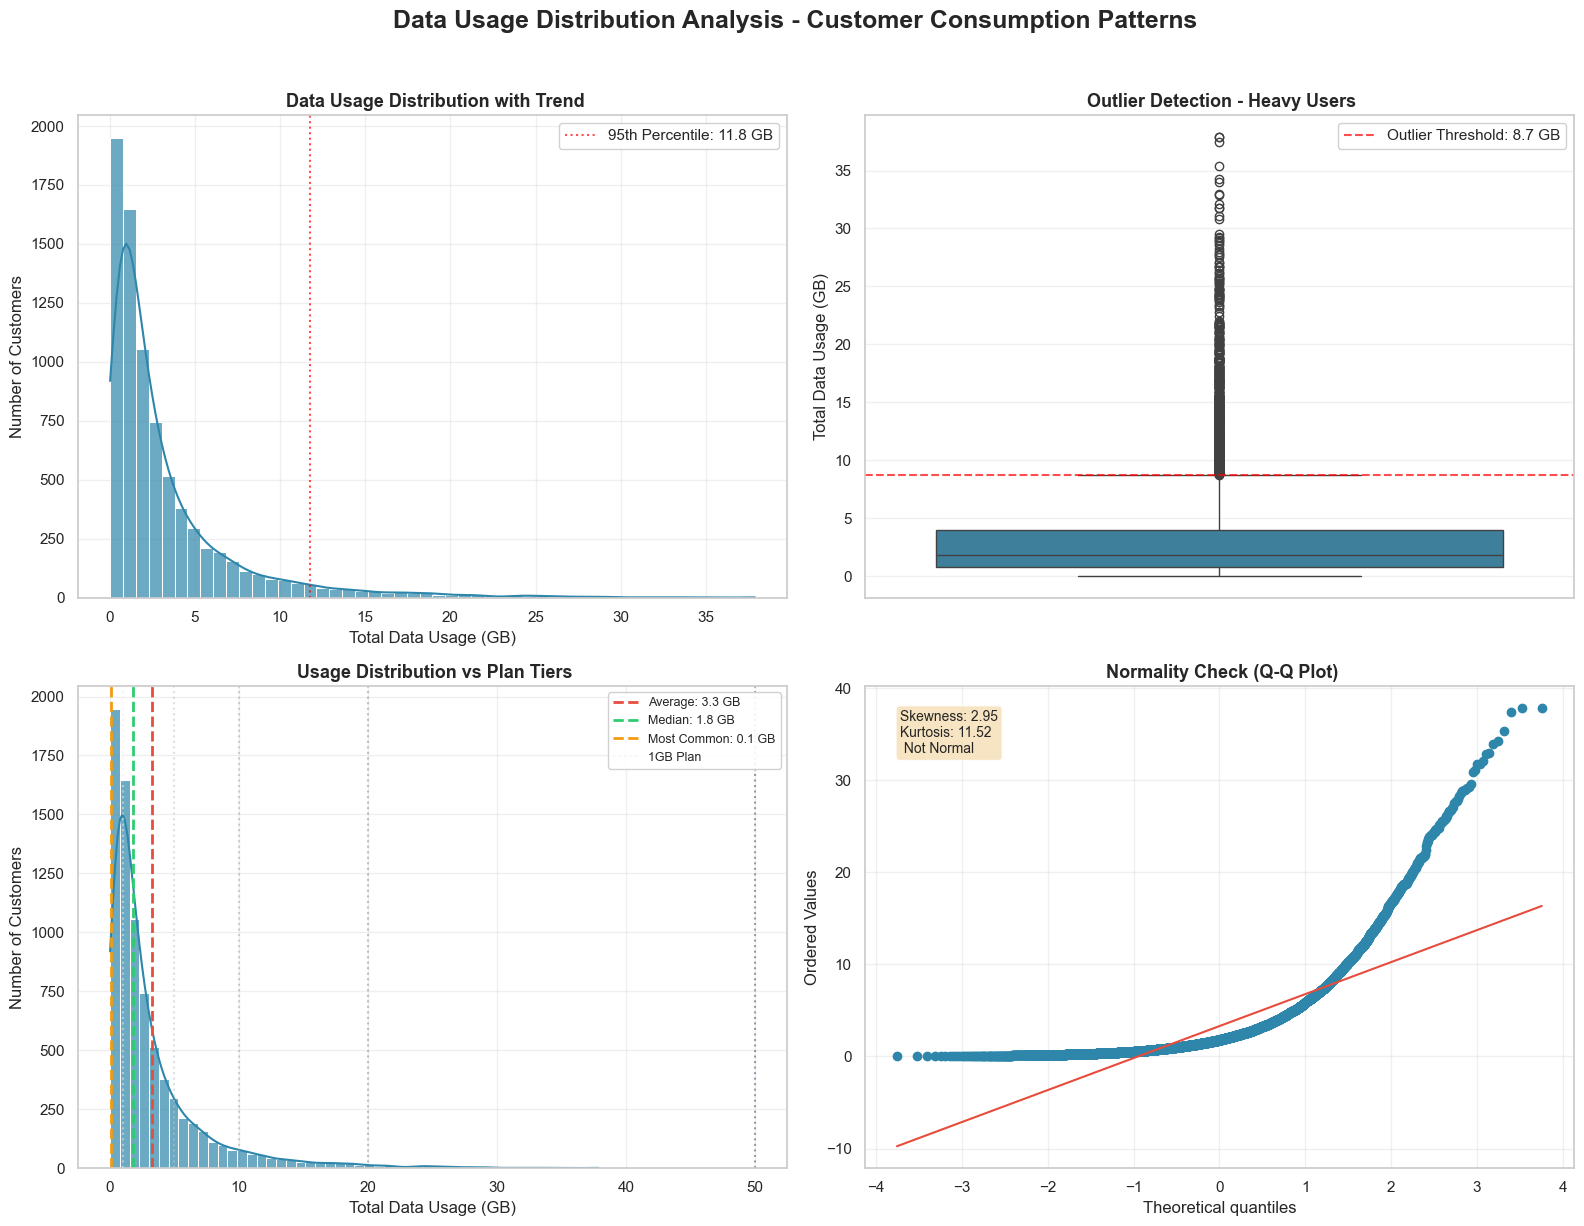

 BUSINESS INSIGHTS - DATA USAGE DISTRIBUTION
• Average Usage: 3.3 GB/customer
• Median Usage: 1.8 GB/customer
• Heavy Users (>95th percentile): 401 customers
• Outliers Detected: 698 customers
• Distribution Shape: Right-Skewed


In [36]:
# ============================================
# TELECOM DATA USAGE DISTRIBUTION ANALYSIS
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(' Data Usage Distribution Analysis - Customer Consumption Patterns', 
             fontsize=18, fontweight='bold', y=1.02)

# Color scheme for telecom
TELECOM_COLOR = '#2E86AB'
TELECOM_PALETTE = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

# 1. Distribution with KDE
sns.histplot(train_df[target_column], bins=50, kde=True, 
             color=TELECOM_COLOR, alpha=0.7, ax=axes[0,0])
axes[0,0].set_title(" Data Usage Distribution with Trend", fontsize=13, fontweight='bold')
axes[0,0].set_xlabel("Total Data Usage (GB)")
axes[0,0].set_ylabel("Number of Customers")
# Add annotation for business context
p95 = train_df[target_column].quantile(0.95)
axes[0,0].axvline(p95, color='red', linestyle=':', alpha=0.7, 
                  label=f'95th Percentile: {p95:.1f} GB')
axes[0,0].legend()

# 2. Box Plot for Outlier Detection
sns.boxplot(y=train_df[target_column], color=TELECOM_COLOR, ax=axes[0,1])
axes[0,1].set_title(" Outlier Detection - Heavy Users", fontsize=13, fontweight='bold')
axes[0,1].set_ylabel("Total Data Usage (GB)")
# Add business insights
q1 = train_df[target_column].quantile(0.25)
q3 = train_df[target_column].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
axes[0,1].axhline(y=upper_bound, color='red', linestyle='--', alpha=0.7, 
                  label=f'Outlier Threshold: {upper_bound:.1f} GB')
axes[0,1].legend()

# 3. Distribution with Business Metrics
sns.histplot(train_df[target_column], bins=50, kde=True, 
             color=TELECOM_COLOR, alpha=0.7, ax=axes[1,0])
mean_val = train_df[target_column].mean()
median_val = train_df[target_column].median()
mode_val = train_df[target_column].mode()[0] if not train_df[target_column].mode().empty else 0

axes[1,0].axvline(mean_val, color='#e74c3c', linestyle='--', linewidth=2, 
                  label=f'Average: {mean_val:.1f} GB')
axes[1,0].axvline(median_val, color='#2ecc71', linestyle='--', linewidth=2, 
                  label=f'Median: {median_val:.1f} GB')
axes[1,0].axvline(mode_val, color='#f39c12', linestyle='--', linewidth=2, 
                  label=f'Most Common: {mode_val:.1f} GB')

# Add plan tiers for business context
plan_tiers = [1, 5, 10, 20, 50]  # Common data plan sizes
colors = ['#ecf0f1', '#bdc3c7', '#95a5a6', '#7f8c8d', '#34495e']
for tier, color in zip(plan_tiers, colors):
    axes[1,0].axvline(tier, color=color, linestyle=':', alpha=0.5, 
                      label=f'{tier}GB Plan' if tier == plan_tiers[0] else "")

axes[1,0].legend(loc='upper right', fontsize=9)
axes[1,0].set_title(" Usage Distribution vs Plan Tiers", fontsize=13, fontweight='bold')
axes[1,0].set_xlabel("Total Data Usage (GB)")
axes[1,0].set_ylabel("Number of Customers")

# 4. Q-Q Plot for Normality Check
from scipy import stats
stats.probplot(train_df[target_column], dist="norm", plot=axes[1,1])
axes[1,1].set_title(" Normality Check (Q-Q Plot)", fontsize=13, fontweight='bold')
axes[1,1].get_lines()[0].set_markerfacecolor(TELECOM_COLOR)
axes[1,1].get_lines()[0].set_markeredgecolor(TELECOM_COLOR)
axes[1,1].get_lines()[1].set_color('#e74c3c')

# Add skewness and kurtosis info
skewness = train_df[target_column].skew()
kurtosis = train_df[target_column].kurtosis()
axes[1,1].text(0.05, 0.95, 
               f'Skewness: {skewness:.2f}\nKurtosis: {kurtosis:.2f}\n{" Not Normal" if abs(skewness) > 0.5 else "✓ Near Normal"}',
               transform=axes[1,1].transAxes, fontsize=10,
               verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

# ============================================
# BUSINESS SUMMARY
# ============================================
print("="*60)
print(" BUSINESS INSIGHTS - DATA USAGE DISTRIBUTION")
print("="*60)
print(f"• Average Usage: {mean_val:.1f} GB/customer")
print(f"• Median Usage: {median_val:.1f} GB/customer")
print(f"• Heavy Users (>95th percentile): {(train_df[target_column] > p95).sum():,} customers")
print(f"• Outliers Detected: {(train_df[target_column] > upper_bound).sum():,} customers")
print(f"• Distribution Shape: {'Right-Skewed' if skewness > 0.5 else 'Normal' if abs(skewness) <= 0.5 else 'Left-Skewed'}")